In [43]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [44]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    
    sr : float
    bpb : float
    boundary_rate : float
    summary : str
    
    

In [45]:
graph = StateGraph(BatsmanState)

In [46]:
def calculate_sr(state : BatsmanState): 
    state['sr'] = (state['runs'] / state['balls']) * 100
    return {'sr' : state['sr']}

In [47]:
def calculate_bpb(state : BatsmanState):
    state['bpb'] = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb' : state['bpb']}

In [48]:
def calculate_boundary_rate(state : BatsmanState):
    state['boundary_rate'] = ((state['fours'] * 4 + state['sixes']*6) / state['balls'])*100
    return {'boundary_rate' : state['boundary_rate']}

In [49]:
def summary(state : BatsmanState) -> BatsmanState:
    summary = f"""
    Strike Rate: {state['sr']} \n
    Balls per Boundary: {state['bpb']} \n
    Boundary Rate: {state['boundary_rate']} \n  
    """
    state['summary'] = summary
    return {'summary' : state['summary']}

In [50]:
graph.add_node("calculate_sr" , calculate_sr)
graph.add_node("calculate_bpb" , calculate_bpb)
graph.add_node("calculate_boundary_rate" , calculate_boundary_rate)
graph.add_node("summary" , summary) 


In [51]:

#edges 

graph.add_edge(START , "calculate_sr")
graph.add_edge(START , "calculate_bpb")
graph.add_edge(START , "calculate_boundary_rate")  

graph.add_edge("calculate_sr" , "summary")
graph.add_edge("calculate_bpb" , "summary")
graph.add_edge("calculate_boundary_rate" , "summary")


In [52]:

graph.add_edge("summary" , END)

# compile

workflow = graph.compile()

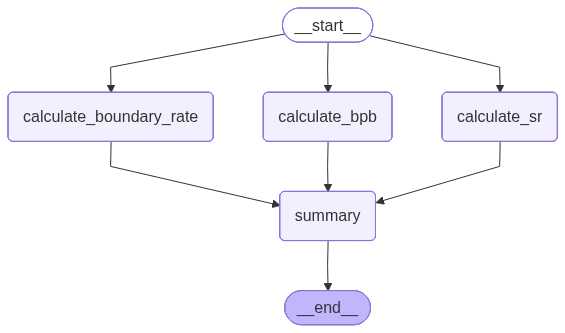

In [53]:
workflow

In [54]:
initial_state = {
    "runs": 120,
    "balls": 80,
    "fours": 10,
    "sixes": 5
}

final_state = workflow.invoke(initial_state)

In [55]:
print(final_state['summary'])


    Strike Rate: 150.0 

    Balls per Boundary: 5.333333333333333 

    Boundary Rate: 87.5 
  
    
